In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from allensdk.brain_observatory.behavior.behavior_project_cache.\
    behavior_neuropixels_project_cache \
    import VisualBehaviorNeuropixelsProjectCache

%matplotlib inline

In [2]:
# Update this to a valid directory in your filesystem. This is where the data will be stored.
cache_dir = './data/'
cache = VisualBehaviorNeuropixelsProjectCache.from_local_cache(cache_dir=cache_dir) #from_s3_cache(cache_dir=cache_dir)

# get the metadata tables
units_table = cache.get_unit_table()
channels_table = cache.get_channel_table()
probes_table = cache.get_probe_table()
behavior_sessions_table = cache.get_behavior_session_table()
ecephys_sessions_table = cache.get_ecephys_session_table()

c:\Users\matth\anaconda3\envs\AMP3-Spring-2026-Project\Lib\site-packages\allensdk\api\cloud_cache\cloud_cache.py:547: OutdatedManifestWarning: You are loading visual-behavior-neuropixels_project_manifest_v0.5.0.json. A more up to date version of the dataset -- visual-behavior-ophys_project_manifest_v1.1.0.json -- exists online. To see the changes between the two versions of the dataset, run
VisualBehaviorNeuropixelsProjectCache.compare_manifests('visual-behavior-neuropixels_project_manifest_v0.5.0.json', 'visual-behavior-ophys_project_manifest_v1.1.0.json')
To load another version of the dataset, run
VisualBehaviorNeuropixelsProjectCache.load_manifest('visual-behavior-ophys_project_manifest_v1.1.0.json')
  warnings.warn(msg, OutdatedManifestWarning)


In [3]:
session_id = 1065437523 #1064644573
session = cache.get_ecephys_session(
            ecephys_session_id=session_id)

c:\Users\matth\anaconda3\envs\AMP3-Spring-2026-Project\Lib\site-packages\hdmf\spec\namespace.py:772: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.6.0-alpha, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


Load Relevant Data

In [4]:
# Get Neural Data
units = session.get_units()
channels = session.get_channels()
unit_channels = units.merge(channels, left_on='peak_channel_id', right_index=True)

#first let's sort our units by depth
unit_channels = unit_channels.sort_values('probe_vertical_position', ascending=False)

#now we'll filter them
good_unit_filter = ((unit_channels['snr']>1)&
                    (unit_channels['isi_violations']<1)&
                    (unit_channels['firing_rate']>0.1))
good_units = unit_channels.loc[good_unit_filter]


# Unit info
unit_indices = np.array(good_units.index)
spike_times = dict([(i,session.spike_times[i]) for i in unit_indices])
structures = dict(good_units.structure_acronym)

# Stimulus Data
stimulus_presentations = session.stimulus_presentations
# Active stimulus
active_stimulus_presentations = stimulus_presentations[stimulus_presentations["active"]]
# Active Stimulus: Time, Name, Is Change
onset_times = active_stimulus_presentations['start_time'].values
image_names = active_stimulus_presentations['image_name'].values
image_is_changes = active_stimulus_presentations['is_change'].values


# Behavioral Data
eye_tracking = session.eye_tracking
running_speed = session.running_speed
licks = session.licks

Pre Compute Bins

In [5]:
# Set bin size (~10 ms)
bin_size = 0.01
# Set # of bins (~10=100ms=0.1 sec)
num_bins = 30

# Create bin times relative to image onset (0ms, 10ms, 20ms, ..., 90ms)
bins_times_per_onset = np.linspace(0, (num_bins-1)*bin_size, num_bins)

# Create bin start and end times for entire active session
bin_start_times = []
bin_end_times = []

# For each image onset
for onset_time in onset_times:
    # Add bin start and end times
    bin_start_times += list(onset_time + bins_times_per_onset)
    bin_end_times += list(onset_time + bins_times_per_onset + bin_size)

# Convert them to numpy arrays (for efficiency)
bin_start_times = np.array(bin_start_times)
bin_end_times = np.array(bin_end_times)

Get Binned Spike Counts

In [6]:
# Get the # of image flashes and # of units
num_image_flashes = len(onset_times)
num_units = len(spike_times)

# Create data structure for binned spike counts
hist = np.zeros((num_image_flashes, num_bins, num_units))

# For each unit
for k, unit_idx in enumerate(unit_indices):
    # Select corresponding unit's spike times
    unit_spike_times = spike_times[unit_idx]

    # Find the correct indices of the unit spike times for each bin
    start_indices = np.searchsorted(unit_spike_times, bin_start_times)
    stop_indices = np.searchsorted(unit_spike_times, bin_end_times)

    # Get the counts for each bin
    counts = stop_indices - start_indices

    # Store them in our handy-dandy "histogram"
    hist[:,:,k] = counts.reshape(num_image_flashes, num_bins)

Do Decoding

In [7]:
unique_images = list(np.unique(image_names))

image_ids = np.zeros(num_image_flashes)
for i,image_name in enumerate(image_names):
    image_ids[i] = unique_images.index(image_name)

In [8]:
is_image_mask = np.ones_like(image_ids, dtype=bool)
omitted_idx = unique_images.index("omitted")
is_image_mask[image_ids == omitted_idx] = False

In [9]:
# Map Structure Acronym to Brain Region
acronym2region = {
    "APN": "Midbrain",
    "CA1": "Hippo",
    "CA3": "Hippo",
    "DG": "Hippo",
    "Eth": "Thalamus",
    "HPF": "Hippo",
    "LP": "Thalamus",
    "MB": "Midbrain",
    "MGd": "Midbrain",
    "MGm": "Midbrain",
    "MGv": "Midbrain",
    "MRN": "Midbrain",
    "NB": "UNKNOWN", # idk
    "NOT": "Midbrain",
    "PIL": "Thalamus",
    "POL": "Thalamus",
    "POST": "Hippo",
    "ProS": "Hippo",
    "SUB": "Hippo",
    "TH": "Thalamus",
    "VISal": "VIS",
    "VISam": "VIS",
    "VISl": "VIS",
    "VISp": "VIS",
    "VISpm": "VIS",
    "VISpm": "VIS",
    "VISrl": "VIS",
    "root": "UNKNOWN", # idk

    "SGN": "Thalamus",
    "PoT": "Thalamus",
    "PP": "Thalamus",
    "RN": "Midbrain", # i think
    "LT": "Midbrain",
}

In [10]:
unique_structures = np.unique(list(structures.values()))

temp_structure_hist = dict([(struct, []) for struct in unique_structures])

for i,unit_idx in enumerate(unit_indices):
    struct = structures[unit_idx]
    temp_structure_hist[struct].append(hist[:,:,i])

min_units = 1

print("Structure and # of good units")
structure_hists = dict()
for key,value in temp_structure_hist.items():
    if len(value) < min_units:
        continue

    print(key, len(value))

    arr = np.stack(value, axis=2)
    structure_hists[key] = arr

Structure and # of good units
APN 111
CA1 172
CA3 45
DG 84
LP 24
LT 1
MB 15
MGm 12
MGv 1
MRN 85
NOT 17
PIL 65
POST 1
PP 49
PoT 55
ProS 89
RN 16
SGN 231
SUB 44
TH 136
VISal 89
VISam 107
VISl 90
VISp 71
VISpm 120
VISrl 73


In [11]:
unique_regions = np.unique(list(acronym2region.values()))

temp_region_hist = dict([(region, []) for region in unique_regions])

for i,unit_idx in enumerate(unit_indices):
    region = acronym2region[structures[unit_idx]]
    temp_region_hist[region].append(hist[:,:,i])

min_units = 1

print("Region and # of good units")
region_hists = dict()
for key,value in temp_region_hist.items():
    if len(value) < min_units:
        continue

    print(key, len(value))

    arr = np.stack(value, axis=2)
    region_hists[key] = arr

Region and # of good units
Hippo 435
Midbrain 258
Thalamus 560
VIS 550


In [12]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

Doing it correctly (cumulative)

In [13]:
num_time_slices = 10
num_structures = len(region_hists)

accs = np.zeros((num_structures, num_time_slices))

Y = image_ids[is_image_mask]

skip = 5

scaler = StandardScaler()

for j,(region, region_hist) in enumerate(region_hists.items()):
    print(region)
    for i in range(num_time_slices):
        X = np.mean(region_hist[:,:i+1,:], axis=1)
        #X = region_hist[:,i,:]

        X = X[is_image_mask]

        X = scaler.fit_transform(X)

        svc = SVC(C=1, kernel="linear")
        svc.fit(X[::skip], Y[::skip])

        y_pred = svc.predict(X[1::skip])
        acc = accuracy_score(Y[1::skip], y_pred)
        accs[j,i] = acc

Hippo
Midbrain
Thalamus
VIS


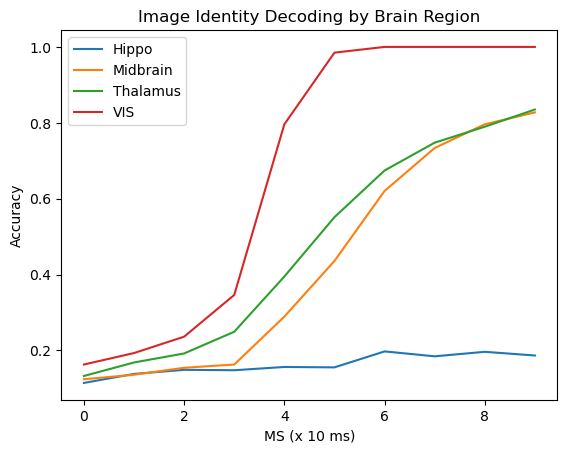

In [14]:
plt.plot(accs.T)
plt.legend(region_hists.keys())
plt.title("Image Identity Decoding by Brain Region")
plt.ylabel("Accuracy")
plt.xlabel("MS (x 10 ms)")
plt.show()

Image Change

In [15]:
from sklearn.linear_model import LogisticRegression

In [16]:
num_time_slices = 30
num_structures = len(region_hists)

accs = np.zeros((num_structures, num_time_slices))

Y = image_is_changes[is_image_mask]

skip = 2

scaler = StandardScaler()

for j,(region, region_hist) in enumerate(region_hists.items()):
    print(region)
    for i in range(num_time_slices):
        X = np.mean(region_hist[:,:i+1,:], axis=1)
        #X = region_hist[:,i,:]

        X = X[is_image_mask]

        X = scaler.fit_transform(X)

        lr = LogisticRegression(class_weight="balanced")
        lr.fit(X[::skip], Y[::skip])

        y_pred = lr.predict(X[1::skip])
        acc = accuracy_score(Y[1::skip], y_pred)
        accs[j,i] = acc

Hippo
Midbrain
Thalamus
VIS


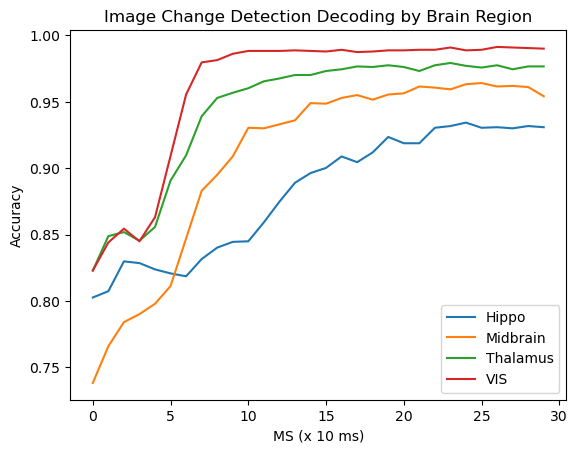

In [17]:
plt.plot(accs.T)
plt.legend(region_hists.keys())
plt.title("Image Change Detection Decoding by Brain Region")
plt.ylabel("Accuracy")
plt.xlabel("MS (x 10 ms)")
plt.show()